In [1]:
import os, sys
import numpy as np 
import matplotlib.pyplot as plt
import torch

def find_root_path(path:str, word:str):
    parts = path.split(word, 1)    
    return parts[0] + word if len(parts) > 1 else path 
root_folder = find_root_path(os.path.abspath(os.getcwd()), 'art_lang')
sys.path.append(root_folder)

from rpod.optimization.parameters import dim_koz, tvec_sec, period
from rpod.dynamics.dynamics_trans import propagate_ct, roe_to_rtn, cim_roe
from rpod.optimization.utils import *

%load_ext autoreload
%autoreload 2

In [2]:
dir_name = 'art_02'
module_path = root_folder + '/rpod/dataset/torch/' + dir_name 
data_param = np.load(module_path + '/dataset-rpod-param.npz', allow_pickle=True)
rtn_cvx = torch.load(module_path + '/torch_states_rtn_cvx.pth').numpy()  
rtn_scp = torch.load(module_path + '/torch_states_rtn_scp.pth').numpy()    
roe_cvx = torch.load(module_path + '/torch_states_roe_cvx.pth').numpy()
roe_scp = torch.load(module_path + '/torch_states_roe_scp.pth').numpy()
a_cvx = torch.load(module_path + '/torch_actions_cvx.pth').numpy()
a_scp = torch.load(module_path + '/torch_actions_scp.pth').numpy()
ctg_cvx = torch.load(module_path + '/torch_ctgs_cvx.pth').numpy()
ctg_scp = torch.load(module_path + '/torch_ctgs_scp.pth').numpy()
rtg_cvx = torch.load(module_path + '/torch_rtgs_cvx.pth').numpy()
rtg_scp = -torch.load(module_path + '/torch_rtgs_scp.pth').numpy()

behav = data_param['behavior']
oe = data_param["oe"]
wyp = data_param["waypoints"]
wyp_times = data_param["waypoint_times"]  

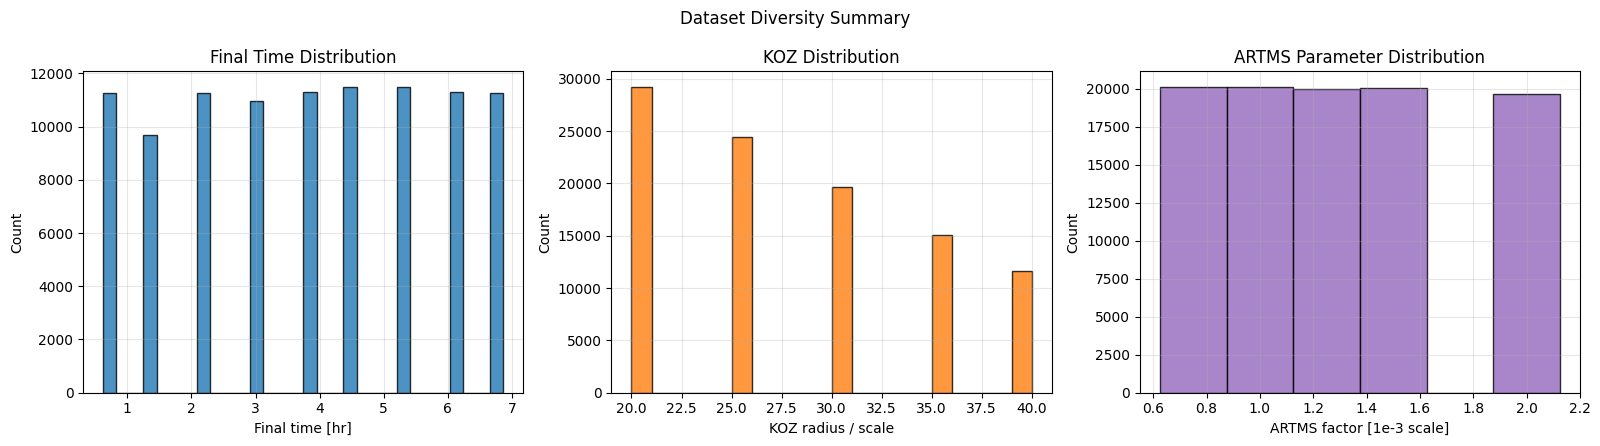

In [3]:
# plot the distribution of final time / koz / artms_parameters 
tf_hours = np.asarray(data_param['tf_sec'], dtype=float).reshape(-1) / 3600.0
artms_param = np.asarray(data_param['artms_param_1e3'], dtype=float).reshape(-1)
koz_dim = np.asarray(data_param['koz_dim'], dtype=float)

if koz_dim.ndim == 1:
    koz_dim = koz_dim.reshape(-1, 1)
elif koz_dim.ndim > 2:
    koz_dim = koz_dim.reshape(koz_dim.shape[0], -1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(tf_hours, bins=30, alpha=0.8, color='tab:blue', edgecolor='black')
axes[0].set_title('Final Time Distribution')
axes[0].set_xlabel('Final time [hr]')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.3)

if koz_dim.shape[1] == 1 or np.allclose(koz_dim, koz_dim[:, [0]]):
    axes[1].hist(koz_dim[:, 0], bins=20, alpha=0.8, color='tab:orange', edgecolor='black')
    axes[1].set_xlabel('KOZ radius / scale')
else:
    koz_labels = ['radial', 'in-track', 'cross-track']
    koz_colors = ['tab:orange', 'tab:green', 'tab:red']
    for k in range(min(3, koz_dim.shape[1])):
        axes[1].hist(koz_dim[:, k], bins=20, alpha=0.55, label=koz_labels[k], color=koz_colors[k])
    axes[1].legend()
    axes[1].set_xlabel('KOZ dimension')
axes[1].set_title('KOZ Distribution')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.3)

axes[2].hist(artms_param, bins=np.arange(artms_param.min() - 0.125, artms_param.max() + 0.25, 0.25), alpha=0.8, color='tab:purple', edgecolor='black')
axes[2].set_title('ARTMS Parameter Distribution')
axes[2].set_xlabel('ARTMS factor [1e-3 scale]')
axes[2].set_ylabel('Count')
axes[2].grid(alpha=0.3)

fig.suptitle('Dataset Diversity Summary')
fig.tight_layout()


Total generated problems: 201975
CVX-feasible rows available for CTG histogram: 201975
  SCP feasible:   100000
  SCP infeasible: 101975


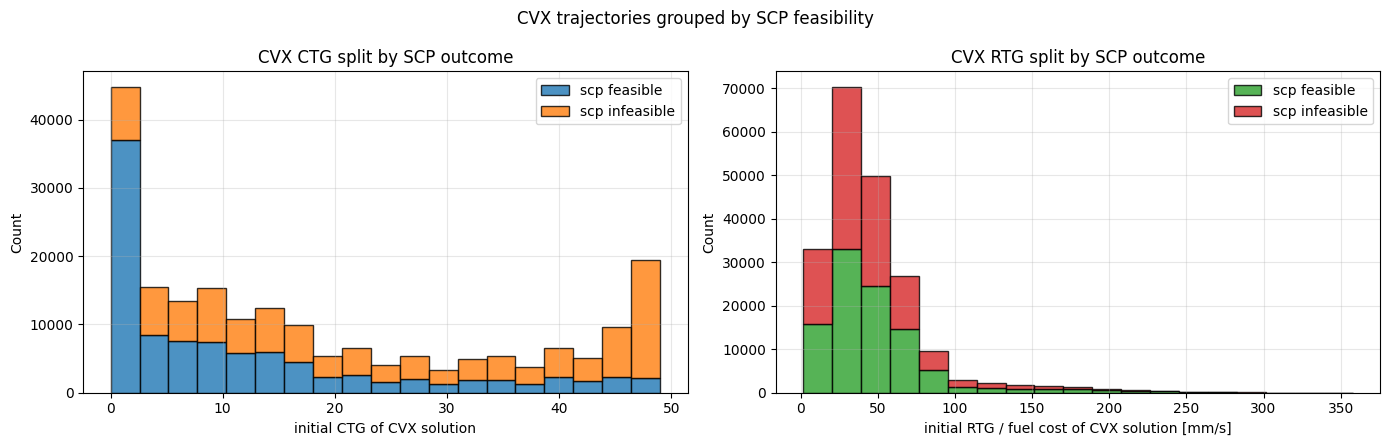

In [4]:
def make_hist_bins(feas, infeas, default_bins=20):
    parts = []
    if feas.size > 0:
        parts.append(feas)
    if infeas.size > 0:
        parts.append(infeas)
    if len(parts) == 0:
        return np.linspace(0.0, 1.0, 8)
    data = np.concatenate(parts)
    bins = np.linspace(data.min(), data.max(), default_bins)
    if np.allclose(bins[0], bins[-1]):
        bins = np.linspace(bins[0] - 0.5, bins[0] + 0.5, 8)
    return bins


n_kept = behav.shape[0]
i_unfeas = np.asarray(data_param['i_unfeas']).reshape(-1).astype(int)
n_removed = i_unfeas.size
n_total = n_kept + n_removed

print(f'Total generated problems: {n_total}')

has_unfiltered = ('ctgs_cvx_unfiltered' in data_param.files) and ('scp_feasible_full' in data_param.files)

scp_feasible_full = np.asarray(data_param['scp_feasible_full'], dtype=bool).reshape(-1)
ctgs_cvx_unfiltered = np.asarray(data_param['ctgs_cvx_unfiltered'], dtype=float)
rtgs_cvx_unfiltered = np.asarray(data_param['rtgs_cvx_unfiltered'], dtype=float) if 'rtgs_cvx_unfiltered' in data_param.files else None

ctg0_all = ctgs_cvx_unfiltered[:, 0, 0]
valid_ctg = np.isfinite(ctg0_all)
ctg_feas = ctg0_all[valid_ctg & scp_feasible_full]
ctg_infeas = ctg0_all[valid_ctg & ~scp_feasible_full]

print(f'CVX-feasible rows available for CTG histogram: {int(valid_ctg.sum())}')
print(f'  SCP feasible:   {int((valid_ctg & scp_feasible_full).sum())}')
print(f'  SCP infeasible: {int((valid_ctg & ~scp_feasible_full).sum())}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist([ctg_feas, ctg_infeas], bins=make_hist_bins(ctg_feas, ctg_infeas), stacked=True, alpha=0.8,
                label=['scp feasible', 'scp infeasible'], color=['tab:blue', 'tab:orange'], edgecolor='black')
axes[0].set_title('CVX CTG split by SCP outcome')
axes[0].set_xlabel('initial CTG of CVX solution')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.3)
axes[0].legend()

if rtgs_cvx_unfiltered is not None:
    rtg0_all = -rtgs_cvx_unfiltered[:, 0, 0] * 1000.0  # mm/s
    valid_rtg = np.isfinite(rtg0_all)
    rtg_feas = rtg0_all[valid_rtg & scp_feasible_full]
    rtg_infeas = rtg0_all[valid_rtg & ~scp_feasible_full]
    axes[1].hist([rtg_feas, rtg_infeas], bins=make_hist_bins(rtg_feas, rtg_infeas), stacked=True, alpha=0.8,
                    label=['scp feasible', 'scp infeasible'], color=['tab:green', 'tab:red'], edgecolor='black')
    axes[1].legend()
    axes[1].set_title('CVX RTG split by SCP outcome')
    axes[1].set_xlabel('initial RTG / fuel cost of CVX solution [mm/s]')
else:
    axes[1].text(0.5, 0.5, 'rtgs_cvx_unfiltered not found', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('CVX RTG split by SCP outcome')
    axes[1].set_xlabel('initial RTG / fuel cost of CVX solution [mm/s]')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.3)

fig.suptitle('CVX trajectories grouped by SCP feasibility')
fig.tight_layout()


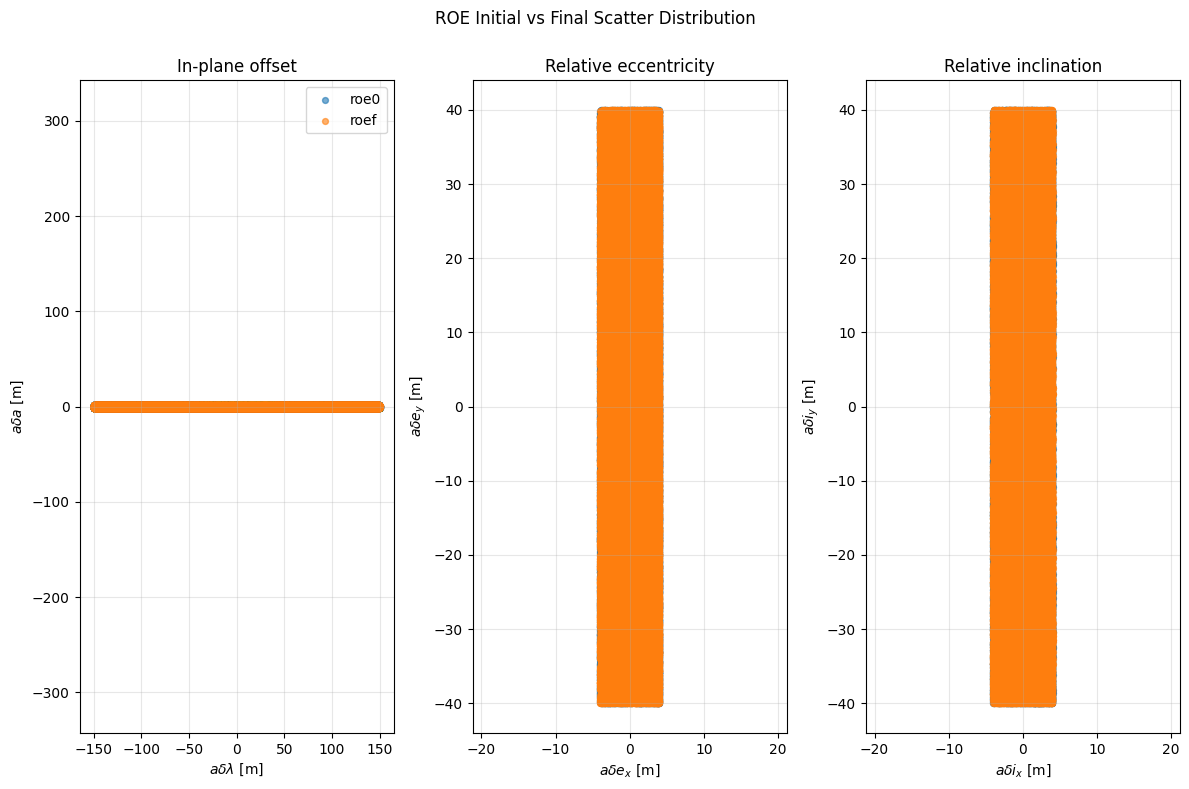

In [5]:
valid_waypoints = np.all(np.isfinite(wyp), axis=2)
valid_counts = valid_waypoints.sum(axis=1)
keep_mask = valid_counts >= 2

row_idx = np.flatnonzero(keep_mask)
roe0 = wyp[row_idx, 0, :]
last_valid_idx = valid_counts[keep_mask] - 1
roef = wyp[row_idx, last_valid_idx, :]

pair_specs = [
    (1, 0, '$a \\delta \\lambda$ [m]', '$a \\delta a$ [m]', 'In-plane offset'),
    (2, 3, '$a \\delta e_x$ [m]', '$a \\delta e_y$ [m]', 'Relative eccentricity'),
    (4, 5, '$a \\delta i_x$ [m]', '$a \\delta i_y$ [m]', 'Relative inclination'),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 8))

for ax, (ix, iy, xlabel, ylabel, title) in zip(axes, pair_specs):
    ax.scatter(roe0[:, ix], roe0[:, iy], s=18, alpha=0.6, color='tab:blue', label='roe0')
    ax.scatter(roef[:, ix], roef[:, iy], s=18, alpha=0.6, color='tab:orange', label='roef')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.axis('equal')

axes[0].legend()
fig.suptitle('ROE Initial vs Final Scatter Distribution')
fig.tight_layout(rect=[0, 0, 1, 0.98])
